In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import spacy.cli
import torch
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, classification_report
import seaborn as sns

In [ ]:
#loading dataset
df = pd.read_csv('sentimentdataset.csv')
#check top 5 entries
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [ ]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
Text,0
Sentiment,0
Timestamp,0
User,0
Platform,0
Hashtags,0
Retweets,0
Likes,0


In [ ]:
# Keep core columns
df = df[['Text', 'Sentiment', 'Platform', 'Country', 'Year', 'Month', 'Day', 'Hour']]

# Drop missing
df = df.dropna(subset=['Text', 'Sentiment'])

# Strip whitespace
df['Text'] = df['Text'].astype(str).str.strip()
df['Sentiment'] = df['Sentiment'].astype(str).str.strip()

In [ ]:
# Example: map to 3-class sentiment
sentiment_map = {
    'Positive': 'positive',
    'Negative': 'negative',
    'Neutral': 'neutral'
}
df_3class = df[df['Sentiment'].isin(sentiment_map.keys())].copy()
df_3class['label'] = df_3class['Sentiment'].map(sentiment_map)

In [ ]:
X_meta = df_3class[['Platform', 'Country', 'Year', 'Month', 'Day', 'Hour']]

ohe = OneHotEncoder(handle_unknown='ignore')
X_cat = ohe.fit_transform(X_meta[['Platform', 'Country']])

scaler = StandardScaler()
X_num = scaler.fit_transform(X_meta[['Year', 'Month', 'Day', 'Hour']])
X_text = df_3class['Text']
y = df_3class['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

bow = CountVectorizer(max_features=5000, ngram_range=(1,2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:

spacy.cli.download("en_core_web_md")
nlp = spacy.load("en_core_web_md")

def doc_vector(text):
    return nlp(text).vector

import numpy as np

X_train_emb = np.vstack([doc_vector(t) for t in X_train])
X_test_emb = np.vstack([doc_vector(t) for t in X_test])

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


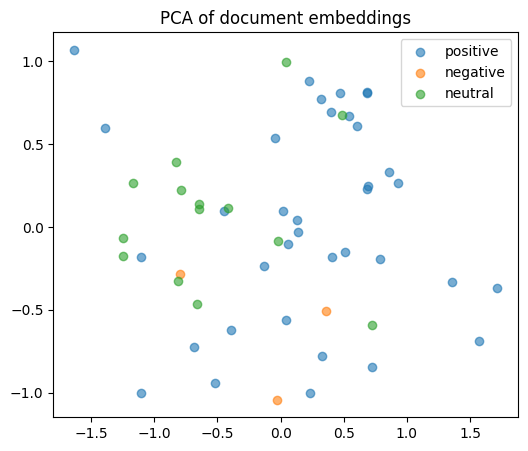

In [ ]:
pca = PCA(n_components=2)
X_emb_2d = pca.fit_transform(X_train_emb)

plt.figure(figsize=(6,5))
for label in ['positive', 'negative', 'neutral']:
    idx = (y_train == label)
    plt.scatter(X_emb_2d[idx,0], X_emb_2d[idx,1], label=label, alpha=0.6)
plt.legend()
plt.title("PCA of document embeddings")
plt.show()

In [ ]:
log_reg = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.1, 1, 10],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    log_reg, param_grid,
    cv=5, scoring='f1_macro', n_jobs=-1
)
grid_lr.fit(X_train_tfidf, y_train)

best_lr = grid_lr.best_estimator_

print("Best parameters:", grid_lr.best_params_)
print("Best score:", grid_lr.best_score_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'C': 0.1, 'class_weight': 'balanced'}
Best score: 0.5785185185185184


In [ ]:
svm = LinearSVC()

param_grid_svm = {
    'C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(
    svm, param_grid_svm,
    cv=5, scoring='f1_macro', n_jobs=-1
)
grid_svm.fit(X_train_tfidf, y_train)

best_svm = grid_svm.best_estimator_

print("Best parameters:", grid_svm.best_params_)
print("Best score:", grid_svm.best_score_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'C': 10}
Best score: 0.5150381263616557


In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
df_bert = df_3class[['Text', 'label']].copy()
label2id = {'negative':0, 'neutral':1, 'positive':2}
df_bert['labels'] = df_bert['label'].map(label2id) # Use 'labels' column name as expected by Trainer
df_bert = df_bert.drop(columns=['label'])

dataset = Dataset.from_pandas(df_bert)

def tokenize_batch(batch):
    return tokenizer(
        batch['Text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [ ]:
dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset_splits = dataset.train_test_split(test_size=0.2, seed=42)

Map:   0%|          | 0/67 [00:00<?, ? examples/s]

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

training_args = TrainingArguments(
    output_dir="./bert_output",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset_splits['train'],
    eval_dataset=tokenized_dataset_splits['test']
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3

Epoch,Training Loss,Validation Loss
1,No log,0.730946
2,No log,0.613124
3,No log,0.588725


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=12, training_loss=0.7995660305023193, metrics={'train_runtime': 312.9765, 'train_samples_per_second': 0.508, 'train_steps_per_second': 0.038, 'total_flos': 10458758354688.0, 'train_loss': 0.7995660305023193, 'epoch': 3.0})

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


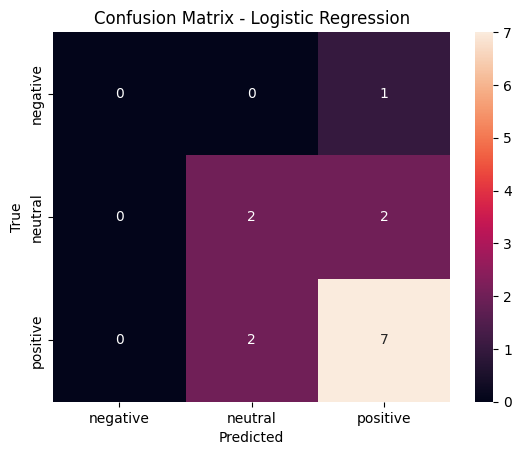

Accuracy: 0.6429
Precision: 0.4000
Recall: 0.4259
F1 Score: 0.4123


In [ ]:
# Example for Logistic Regression
y_pred_lr = best_lr.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred_lr)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='macro')

cm = confusion_matrix(y_test, y_pred_lr, labels=['negative','neutral','positive'])

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
